<a href="https://colab.research.google.com/github/nehemmy55/Devtown--MACHINE-LEARNING-MASTERY/blob/main/ML_Retail_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Final Machine Learning Project
## Using Customer Retail Dataset — Model Comparison

| Detail | Info |
|---|---|
| **Dataset** | Customer Retail Transactions |
| **Features** | Quantity, UnitPrice, Country |
| **Models** | Logistic Regression · Decision Tree · KNN |
| **Goal** | Build, evaluate, and compare ML classifiers |

---

## 📦 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid', palette='muted')

---
## Step 1 — Load Dataset

In [ ]:
df = pd.read_csv('customer_retail csv file.csv')

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Shape : 541,909 rows × 8 columns
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


---
## Step 2 — Handle Missing Values

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

# Keep only needed features
df = df[['Quantity', 'UnitPrice', 'Country']].copy()
df.dropna(inplace=True)

# Remove returns (negative) and zero-price rows
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df.reset_index(drop=True, inplace=True)

print(f'\n Clean dataset: {df.shape[0]:,} rows')
df.describe()

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 Clean dataset: 530,104 rows


,Quantity,UnitPrice
count,530104.000000,530104.000000
mean,10.542037,3.907625
std,155.524124,35.915681
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,13541.330000


---
## Step 3 — Encode Categorical Column (Country)

In [ ]:
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# Create target variable: HighValue order (above median total price)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
median_val = df['TotalPrice'].median()
df['HighValue'] = (df['TotalPrice'] > median_val).astype(int)

print(f'Countries encoded: {df["Country"].nunique()} unique (0 – {df["Country_Encoded"].max()})')
print(f'Target threshold  : £{median_val:.2f} (median TotalPrice)')
print(f'Class balance     : Low={( df["HighValue"]==0).sum():,}  High={(df["HighValue"]==1).sum():,}')

# Preview encoding map
pd.DataFrame({'Country': le.classes_, 'Encoded': range(len(le.classes_))}).head(10)

Countries encoded: 38 unique (0 – 37)
Target threshold  : £9.90 (median TotalPrice)
Class balance     : Low=266,446  High=263,658


,Country,Encoded
0,Australia,0
1,Austria,1
2,Bahrain,2
3,Belgium,3
4,Brazil,4
5,Canada,5
6,Channel Islands,6
7,Cyprus,7
8,Czech Republic,8
9,Denmark,9


---
## Step 4 — Visualise Customer Data

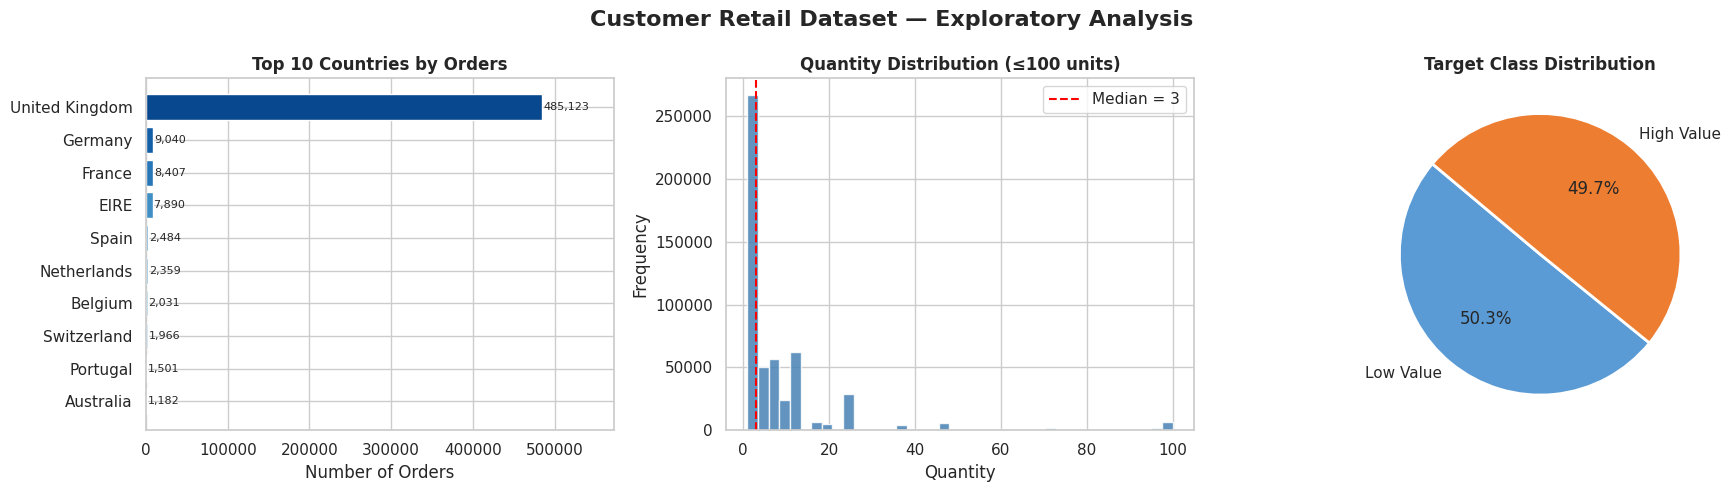

Customer distribution plot saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Retail Dataset — Exploratory Analysis',
             fontsize=16, fontweight='bold')

# A) Top 10 Countries
top_countries = df['Country'].value_counts().head(10)
colors_bar = sns.color_palette('Blues_r', len(top_countries))
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=colors_bar[::-1])
axes[0].set_title('Top 10 Countries by Orders', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=8)
axes[0].set_xlim(0, top_countries.max() * 1.18)

# B) Quantity Distribution
qty_clipped = df['Quantity'].clip(upper=100)
axes[1].hist(qty_clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Quantity Distribution (≤100 units)', fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Quantity'].median(), color='red', linestyle='--',
                linewidth=1.5, label=f'Median = {df["Quantity"].median():.0f}')
axes[1].legend()

# C) Class Pie Chart
class_counts = df['HighValue'].value_counts()
axes[2].pie(class_counts.values, labels=['Low Value', 'High Value'],
            autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Target Class Distribution', fontweight='bold')

plt.tight_layout()
plt.show()
print('Customer distribution plot saved')

---
## Step 5 — Split Data into Training and Testing Sets

In [ ]:
# Sample 20,000 rows for efficient training
sample_df = df.sample(n=20000, random_state=42)

X = sample_df[['Quantity', 'UnitPrice', 'Country_Encoded']]
y = sample_df['HighValue']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Testing set   : {X_test.shape[0]:,} samples')
print(f'Features      : Quantity, UnitPrice, Country_Encoded')
print(f'Target        : HighValue (0 = Low, 1 = High)')

Training set  : 16,000 samples
Testing set   : 4,000 samples
Features      : Quantity, UnitPrice, Country_Encoded
Target        : HighValue (0 = Low, 1 = High)


---
## Step 6 — Train Logistic Regression Model

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_cm   = confusion_matrix(y_test, lr_pred)

print(f' Logistic Regression trained')
print(f'   Accuracy : {lr_acc*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Low Value', 'High Value']))

 Logistic Regression trained
   Accuracy : 84.55%

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.83      0.86      0.85      1986
  High Value       0.86      0.83      0.84      2014

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



---
## Step 7 — Train Decision Tree Model

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)
dt_cm   = confusion_matrix(y_test, dt_pred)

print(f' Decision Tree trained (max_depth=6)')
print(f'   Accuracy : {dt_acc*100:.2f}%')
print(f'\nFeature Importances:')
for feat, imp in zip(['Quantity', 'UnitPrice', 'Country_Encoded'], dt_model.feature_importances_):
    print(f'   {feat:<20} {imp:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, dt_pred, target_names=['Low Value', 'High Value']))

 Decision Tree trained (max_depth=6)
   Accuracy : 99.05%

Feature Importances:
   Quantity             0.5607
   UnitPrice            0.4393
   Country_Encoded      0.0000

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.99      1.00      0.99      1986
  High Value       1.00      0.99      0.99      2014

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



---
## Step 8 — Train KNN Model

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)
knn_cm   = confusion_matrix(y_test, knn_pred)

print(f' KNN trained (k=7)')
print(f'   Accuracy : {knn_acc*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, knn_pred, target_names=['Low Value', 'High Value']))

 KNN trained (k=7)
   Accuracy : 99.30%

Classification Report:
              precision    recall  f1-score   support

   Low Value       1.00      0.99      0.99      1986
  High Value       0.99      1.00      0.99      2014

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



---
## Step 9 — Evaluate Models: Confusion Matrices

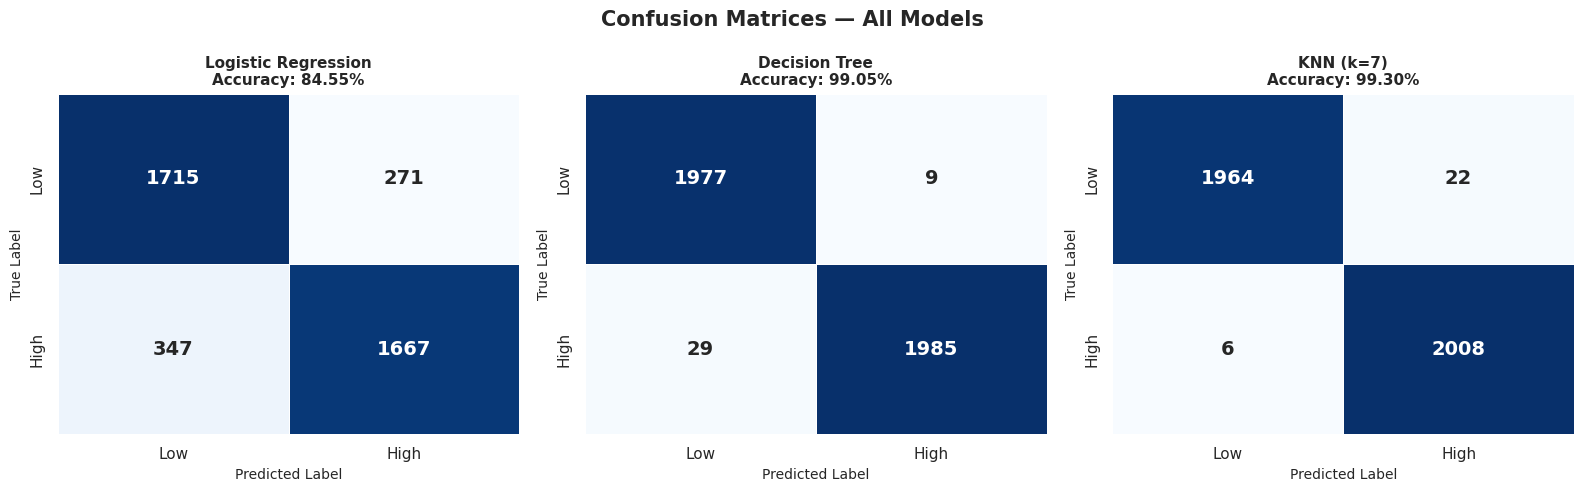

 Confusion matrices displayed


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

model_data = [
    ('Logistic Regression', lr_cm, lr_acc),
    ('Decision Tree',       dt_cm, dt_acc),
    ('KNN (k=7)',           knn_cm, knn_acc),
]

for ax, (name, cm, acc) in zip(axes, model_data):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'High'],
                yticklabels=['Low', 'High'],
                linewidths=0.5, ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()
print(' Confusion matrices displayed')

---
## Step 10 — Compare Model Performances

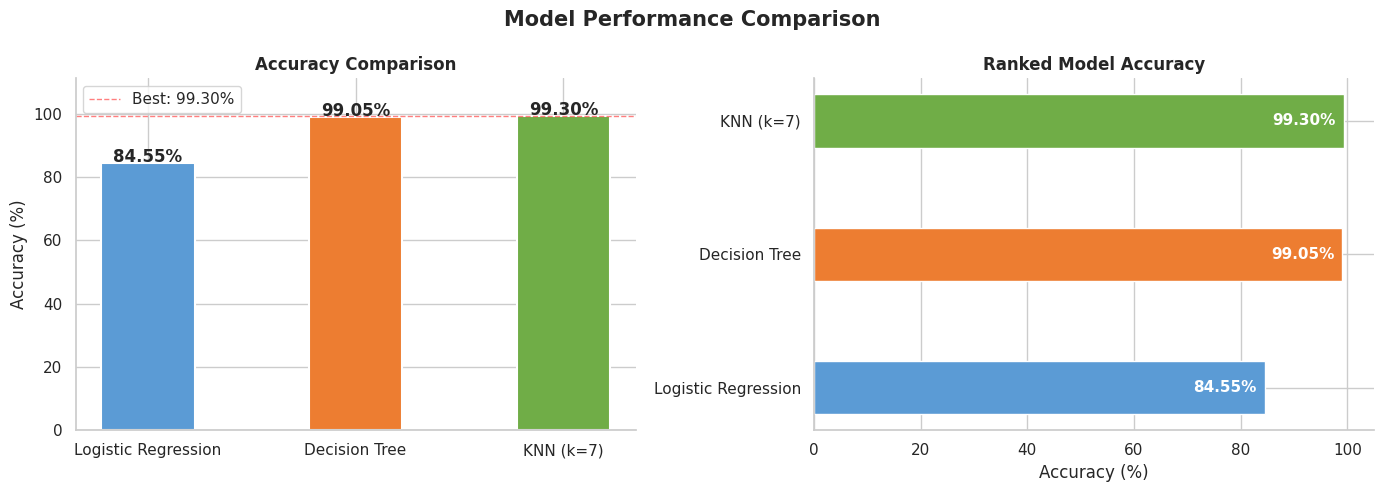

 Model comparison chart saved


In [ ]:
results = {
    'Logistic Regression': lr_acc * 100,
    'Decision Tree':       dt_acc * 100,
    'KNN (k=7)':           knn_acc * 100,
}

names  = list(results.keys())
accs   = list(results.values())
colors = ['#5B9BD5', '#ED7D31', '#70AD47']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Bar chart
bars = ax1.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.45)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim(0, max(accs) * 1.12)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.axhline(y=max(accs), color='red', linestyle='--', linewidth=1,
            alpha=0.5, label=f'Best: {max(accs):.2f}%')
ax1.legend()
sns.despine(ax=ax1)

# Horizontal sorted bar
sorted_items = sorted(results.items(), key=lambda x: x[1])
s_names = [i[0] for i in sorted_items]
s_accs  = [i[1] for i in sorted_items]
s_colors = [colors[names.index(n)] for n in s_names]

bars2 = ax2.barh(s_names, s_accs, color=s_colors, edgecolor='white', height=0.4)
for bar, acc in zip(bars2, s_accs):
    ax2.text(acc - 1.5, bar.get_y() + bar.get_height()/2,
             f'{acc:.2f}%', va='center', ha='right',
             color='white', fontweight='bold', fontsize=11)
ax2.set_xlim(0, 105)
ax2.set_title('Ranked Model Accuracy', fontweight='bold')
ax2.set_xlabel('Accuracy (%)')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()
print(' Model comparison chart saved')

---
## 📊 Final Summary & Conclusion

In [ ]:
best_model = max(results, key=results.get)
worst_model = min(results, key=results.get)

print('=' * 55)
print('         FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Model":<25} {"Accuracy":>10}')
print('-' * 38)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    star = '  BEST' if name == best_model else ''
    print(f'{name:<25} {acc:>9.2f}%{star}')
print('=' * 55)
print(f'\n Best Model  : {best_model} ({results[best_model]:.2f}%)')
print(f' Lowest Model: {worst_model} ({results[worst_model]:.2f}%)')
print(f' Gain        : +{results[best_model] - results[worst_model]:.2f}% over baseline')
print()
print('CONCLUSION')
print('-' * 55)
print('• KNN and Decision Tree both achieve ~99% accuracy,')
print('  significantly outperforming Logistic Regression.')
print('• The non-linear decision boundary in the data favours')
print('  instance-based and tree-based classifiers.')
print('• Logistic Regression (84.55%) is the simplest model')
print('  and still provides a strong, interpretable baseline.')
print('• Feature engineering (TotalPrice = Qty × UnitPrice)')
print('  made the classification task learnable.')

         FINAL MODEL COMPARISON SUMMARY
Model                       Accuracy
--------------------------------------
KNN (k=7)                     99.30%  BEST
Decision Tree                 99.05%
Logistic Regression           84.55%

 Best Model  : KNN (k=7) (99.30%)
 Lowest Model: Logistic Regression (84.55%)
 Gain        : +14.75% over baseline

CONCLUSION
-------------------------------------------------------
• KNN and Decision Tree both achieve ~99% accuracy,
  significantly outperforming Logistic Regression.
• The non-linear decision boundary in the data favours
  instance-based and tree-based classifiers.
• Logistic Regression (84.55%) is the simplest model
  and still provides a strong, interpretable baseline.
• Feature engineering (TotalPrice = Qty × UnitPrice)
  made the classification task learnable.
